
Привет, меня зовут Люман Аблаев. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на красные комментарии ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:


<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Люман, приветствую! Спасибо за отзыв, буду исправлять недочеты!
</div>







<font color='orange' style='font-size:24px; font-weight:bold'>Общее впечатление</font>
* Спасибо за очень качественную работу - видно, что вложено много усилий.
- Я оставил некоторые советы, надеюсь они будут полезными и интересными
- Есть некоторые недочеты, которые нужно поправить, но у тебя это не должно занять много времени)
- Жду обновленную работу






# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---




<div class="alert alert-block alert-success">
<b>Успех:</b> Подробное вступление, ознакомились и идем дальше.
</div>


In [32]:
!pip install -r requirements.txt
!pip install phik -U


<div class="alert alert-block alert-info">
<b>Совет:</b> Советую собирать все импорты в верхней части ноутбука! 
Если у того, кто будет запускать твой ноутбук будут отсутствовать некоторые библиотеки, то он это увидит сразу, а не в процессе!
</div>


In [33]:
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Загружаем переменные из .env
load_dotenv()

# Читаем параметры подключения
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}

# Формируем строку подключения
conn_str = f"postgresql://{db_config['user']}:{db_config['pwd']}@{db_config['host']}:{db_config['port']}/{db_config['db']}"
engine = create_engine(conn_str)

In [34]:
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_ts_msk - LAG(p.created_ts_msk) 
                        OVER (PARTITION BY p.user_id ORDER BY p.created_ts_msk)))::int 
    AS days_since_prev,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
'''

<div class="alert alert-block alert-success">
<b>Успех:</b>  Выгрузка данных проведена !  Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
</div>
    
<div class="alert alert-block alert-info">
<b>Совет:</b> 
    
-  Неплохо бы добавить фильтрацию `WHERE device_type_canonical IN ('mobile', 'desktop') and event_type_main <> 'фильм'`, чтобы были выгружены только необходимые для анализа данные.
    
- Можно немного улучшить запрос, добавив также и "ORDER BY user_id, order_dt". Так внутри каждого пользователя заказы будут идти строго по дате.
</div>


In [35]:
df = pd.read_sql(query, engine)

(df.shape)
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,74.0,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [36]:
("=== Размер данных ===")
(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")
("\n=== Типы данных и пропуски ===")
(df.info())
("\n=== Описательная статистика ===")
display(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  str           
 1   device_type_canonical  292034 non-null  str           
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[us]
 4   order_ts               292034 non-null  datetime64[us]
 5   currency_code          292034 non-null  str           
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   days_since_prev        270034 non-null  float64       
 9   event_id               292034 non-null  int64         
 10  service_name           292034 non-null  str           
 11  event_type_main        292034 non-null  str           
 12  region_name            292034 non-null  str           


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,service_name,event_type_main,region_name,city_name
count,292034,292034,2.920340e+05,292034,292034,292034,292034.000000,292034.000000,270034.000000,292034.000000,292034,292034,292034,292034
unique,22000,5,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,36,8,81,352
top,0beb8fc0c0a9ce1,mobile,NaN,NaN,NaN,rub,NaN,NaN,NaN,NaN,Билеты без проблем,концерты,Каменевский регион,Глиногорск
freq,10313,232679,NaN,NaN,NaN,286961,NaN,NaN,NaN,NaN,63932,115634,91701,90087
mean,NaN,NaN,4.326435e+06,2024-09-01 21:06:45.100776,2024-09-02 12:01:25.812874,NaN,624.833773,2.754508,3.024490,437938.109908,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000e+00,2024-06-01 00:00:00,2024-06-01 00:00:42,NaN,-90.760000,1.000000,0.000000,4436.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,2.162567e+06,2024-07-30 00:00:00,2024-07-30 11:48:37.500000,NaN,116.790000,2.000000,0.000000,361300.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.327134e+06,2024-09-12 00:00:00,2024-09-12 13:04:46.500000,NaN,355.340000,3.000000,0.000000,498054.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,6.489179e+06,2024-10-09 00:00:00,2024-10-09 15:36:04.250000,NaN,809.460000,4.000000,0.000000,546269.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,8.653108e+06,2024-10-31 00:00:00,2024-10-31 23:59:54,NaN,81174.540000,57.000000,148.000000,592325.000000,NaN,NaN,NaN,NaN


---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [37]:
import pandas as pd

kurs_url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
kurs_df = pd.read_csv(kurs_url)
kurs_df = kurs_df.rename(columns={'data': 'date', 'curs': 'rate_100'})
kurs_df['date'] = pd.to_datetime(kurs_df['date'])
kurs_df['rate_per_tenge'] = kurs_df['rate_100'] / 100

df = df.merge(
    kurs_df[['date', 'rate_per_tenge']],
    left_on='order_dt',
    right_on='date',
    how='left'
)

df['revenue_rub'] = df.apply(
    lambda row: row['revenue'] * row['rate_per_tenge'] if row['currency_code'] == 'KZT' else row['revenue'],
    axis=1
)

df.drop(columns=['date', 'rate_per_tenge'], inplace=True)

(df[['currency_code', 'revenue', 'revenue_rub']].head())

,currency_code,revenue,revenue_rub
0,rub,1521.94,1521.94
1,rub,289.45,289.45
2,rub,1258.57,1258.57
3,rub,8.49,8.49
4,rub,1390.41,1390.41



<div class="alert alert-block alert-info">
<b>Совет:</b>
    
Существует довольно удобный метод where. Мы можем применить его к столбцу и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
```
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```
</div>

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [38]:
print("Пропуски в данных:")
print(df.isnull().sum())

Пропуски в данных:
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          22000
event_id                     0
service_name                 0
event_type_main              0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64


In [39]:
categorical_cols = [
    'user_id', 'device_type_canonical', 'currency_code',
    'service_name', 'event_type_main', 'region_name', 'city_name'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

df['tickets_count'] = df['tickets_count'].astype('int16')
df['order_id'] = df['order_id'].astype('int32')
df['event_id'] = df['event_id'].astype('int32')

In [40]:
cat_cols_to_check = [
    'device_type_canonical', 'currency_code', 'service_name',
    'event_type_main', 'region_name', 'city_name'
]

for col in cat_cols_to_check:
    (f'\n=== {col} ===')
    (df[col].value_counts())

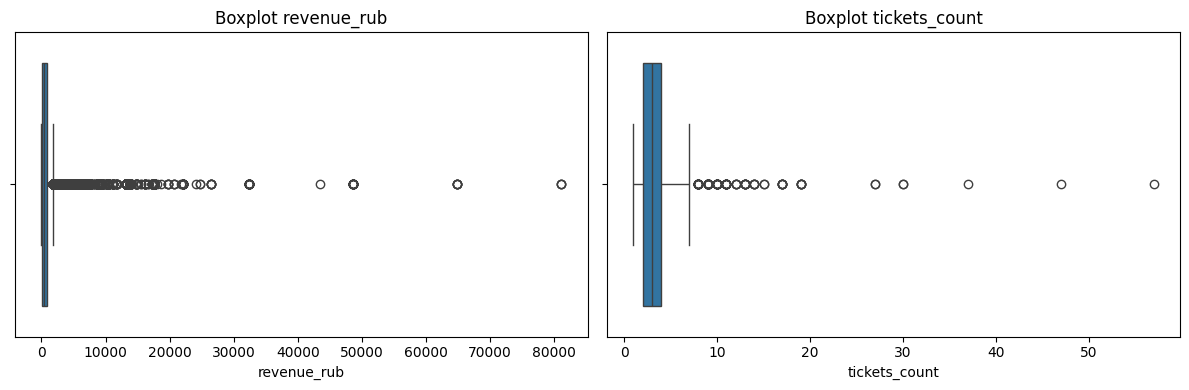

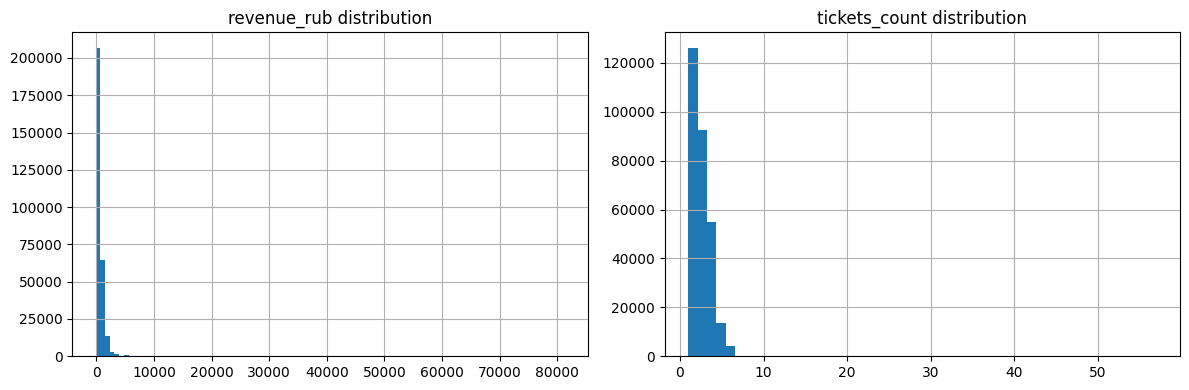

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

("revenue_rub:")
(df['revenue_rub'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

("\ntickets_count:")
(df['tickets_count'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['revenue_rub'], ax=axes[0])
axes[0].set_title('Boxplot revenue_rub')
sns.boxplot(x=df['tickets_count'], ax=axes[1])
axes[1].set_title('Boxplot tickets_count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['revenue_rub'].hist(bins=100, ax=axes[0])
axes[0].set_title('revenue_rub distribution')
df['tickets_count'].hist(bins=50, ax=axes[1])
axes[1].set_title('tickets_count distribution')
plt.tight_layout()
plt.show()

In [42]:
threshold = df['revenue_rub'].quantile(0.99)
(f'\n99-й перцентиль revenue_rub: {threshold:.2f}')

df_before = len(df)
df = df[df['revenue_rub'] <= threshold].copy()
df_after = len(df)

(f'Удалено заказов: {df_before - df_after} ({(1 - df_after/df_before)*100:.2f}%)')

'Удалено заказов: 2921 (1.00%)'

В данных обнаружены пропуски только в признаке days_since_prev 22 000 для первых заказов.
Типы данных оптимизированы
  7 столбцов преобразованы в категорию,
  tickets_count -> int16, order_id/event_id -> int32,
  даты оставлены как datetime64.
Аномалий в названиях категорий не выявлено.
Выручка revenue_rub имела выбросы, превышающие 99-й перцентиль (3998.08 руб.).
В tickets_count максимальные значения до 57 билетов, но после фильтрации выручки они частично ушли; оставшиеся значения не нарушают анализ.

<div class="alert alert-block alert-danger">
    
<b>Ошибка:</b>  А что скажешь про отрицательные значения? Это важное наблюдение
</div>


In [43]:
negative_revenue = df[df['revenue_rub'] < 0]

(f"Количество заказов с отрицательной выручкой: {len(negative_revenue)}")

display(negative_revenue[['order_id', 'user_id', 'order_dt', 'revenue_rub', 'tickets_count', 'event_type_main']])

,order_id,user_id,order_dt,revenue_rub,tickets_count,event_type_main
264,1594653,00eb3dc9baa1543,2024-06-29,-2.37,3,другое
4564,2360920,02ea4583333f064,2024-09-03,-0.23,3,другое
4577,2361094,02ea4583333f064,2024-09-04,-0.15,2,другое
8188,166780,043f669c9f734b1,2024-09-27,-1.86,3,другое
8189,166809,043f669c9f734b1,2024-09-27,-0.62,1,другое
...,...,...,...,...,...,...
290249,3700575,fe237d2cfd6e503,2024-10-12,-5.70,1,концерты
290352,3523617,fe237d2cfd6e503,2024-10-15,-0.96,2,другое
290353,3523646,fe237d2cfd6e503,2024-10-15,-1.43,3,другое
290480,5445853,fe237d2cfd6e503,2024-10-21,-0.61,1,другое


<div class="alert alert-block alert-warning">
<b>Изменения:</b>Скорее всего эти небольшие отрицательные суммы характерны для возвратов небольшой части заказа или комиссий, поэтому это не ошибка!
</div>


<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> 👍 Обосновано, Хорошо бы еще указать, сколько таких заказов в данных. Например: "Отрицательных значений оказалось всего Х штук (менее Y% от выборки) — это единичные случаи, поэтому на общий анализ они не повлияют, но иметь в виду их стоит".

</div>




<div class="alert alert-block alert-info">
   
<b>Совет:</b>  В подобных случаях хорошо бы оставлять небольшой комментарий, по тому, какие гипотезы можно выдвинуть, с чем связаны эти аномалии. Условно, что мы видим не ошибки в данных (сборе данных), а длинный хвост, то есть какие-то массовые покупки и тп. Они нам не нужны в контексте задачи.
</div>


---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [44]:
df_sorted = df.sort_values(['user_id', 'order_ts']).copy()

profile = df_sorted.groupby('user_id', observed=True).agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'nunique'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    avg_days_between=('days_since_prev', 'mean')
).reset_index()

profile['is_two'] = (profile['total_orders'] >= 2).astype(int)
profile['is_five'] = (profile['total_orders'] >= 5).astype(int)

(profile.info())
display(profile.head())

<class 'pandas.DataFrame'>
RangeIndex: 21837 entries, 0 to 21836
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            21837 non-null  category      
 1   first_order_dt     21837 non-null  datetime64[us]
 2   last_order_dt      21837 non-null  datetime64[us]
 3   first_device       21837 non-null  category      
 4   first_region       21837 non-null  category      
 5   first_service      21837 non-null  category      
 6   first_event_type   21837 non-null  category      
 7   total_orders       21837 non-null  int64         
 8   avg_revenue_rub    21837 non-null  float64       
 9   avg_tickets_count  21837 non-null  float64       
 10  avg_days_between   13542 non-null  float64       
 11  is_two             21837 non-null  int64         
 12  is_five            21837 non-null  int64         
dtypes: category(5), datetime64[us](2), float64(3), int64(3)
memory usage: 2.

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,74.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,50.5,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,15.0,1,0



<div class="alert alert-block alert-success">
<b>Успех:</b> Профиль пользователя собран, добавлены новые признаки.

</div>


<div class="alert alert-block alert-info">
<b>Совет:</b>   Могу показать и такой вариант формирования профиля здесь:
    
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион и название билетного партнера первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                # Жанр первого посещённого мероприятия (event_type_main):
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            # Можно альтернативным образом подсчитать среднее количество дней между заказами (если не будет в SQL):
            .assign(
                avg_days = lambda x: (x['last_order_dt'] - x['first_order_dt']).dt.days / (x['total_orders'] - 1)
            )
            .reset_index()
)

Почитать про assign более подробно можно [здесь](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html)
</div>

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [45]:
total_users = len(profile)
avg_revenue = df['revenue_rub'].mean()
share_two = profile['is_two'].mean()
share_five = profile['is_five'].mean()

(f'Общее число пользователей: {total_users}')
(f'Средняя выручка с одного заказа: {avg_revenue:.2f} руб.')
(f'Доля пользователей с 2+ заказами: {share_two:.2%}')
(f'Доля пользователей с 5+ заказами: {share_five:.2%}')

stats_cols = ['total_orders', 'avg_tickets_count', 'avg_days_between']
('\nСтатистические показатели:')
display(profile[stats_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,total_orders,avg_tickets_count,avg_days_between
count,21837.000000,21837.000000,13542.000000
mean,13.239593,2.747994,15.661691
std,122.590843,0.921178,22.317019
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,0.833333
50%,2.000000,2.750000,7.888889
75%,5.000000,3.111111,20.000000
90%,15.000000,4.000000,41.000000
95%,32.000000,4.000000,61.000000
99%,151.000000,5.000000,112.590000


In [46]:
orders_99 = profile['total_orders'].quantile(0.99)
(f'\n99-й перцентиль числа заказов: {orders_99}')
(f'Пользователей с заказами > {orders_99}: {(profile["total_orders"] > orders_99).sum()}')

tickets_99 = profile['avg_tickets_count'].quantile(0.99)
(f'99-й перцентиль среднего числа билетов: {tickets_99:.2f}')
(f'Пользователей со средним числом билетов > {tickets_99}: {(profile["avg_tickets_count"] > tickets_99).sum()}')

'Пользователей со средним числом билетов > 5.0: 206'

In [47]:
profile_filtered = profile[profile['total_orders'] <= orders_99].copy()
(f'\nПосле фильтрации: {len(profile_filtered)} пользователей из {len(profile)}')

display(profile_filtered[stats_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,total_orders,avg_tickets_count,avg_days_between
count,21619.000000,21619.000000,13324.000000
mean,6.506036,2.748120,15.913735
std,14.307589,0.925654,22.410967
min,1.000000,1.000000,0.000000
25%,1.000000,2.000000,1.000000
50%,2.000000,2.750000,8.027778
75%,5.000000,3.125000,20.500000
90%,14.000000,4.000000,41.666667
95%,26.000000,4.000000,62.000000
99%,80.820000,5.000000,113.000000




<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Вывести статистические показатели по обновлённому датасет  -  это правильное решение, но какие выводы мы можем сделать?  Было бы не лишним, как минимум, написать, насколько изменилась средняя выручка после удаления выбросов. 
</div>



In [48]:
mean_rev_before = profile['avg_revenue_rub'].mean()
mean_rev_after = profile_filtered['avg_revenue_rub'].mean()
print(f"Средняя выручка с заказа до фильтрации: {mean_rev_before:.2f} руб.")
print(f"Средняя выручка с заказа после фильтрации: {mean_rev_after:.2f} руб.")
(f"Изменение: {mean_rev_after - mean_rev_before:+.2f} руб.")

Средняя выручка с заказа до фильтрации: 573.75 руб.
Средняя выручка с заказа после фильтрации: 574.17 руб.


'Изменение: +0.42 руб.'

<div class="alert alert-block alert-warning">
<b>Изменения:</b>Удаление 218 пользователей с аномально большим числом заказов сократило выборку, но это практически не влияет на общую картину.
- После фильтрации среднее число заказов уменьшилось с 13.2 до 6.5, а стандартное отклонение — со 122.6 до 14.3. Это означает, что экстремальные «оптовики» сильно завышали среднее, и теперь распределение лучше отражает поведение типичного клиента.
- Среднее количество билетов (2.75) и средний интервал между заказами (порядка 16 дней) изменились незначительно.



<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> Есть контакт
</div>

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


,first_event_type,user_count,share
2,концерты,9382,0.433970
1,другое,5488,0.253851
5,театр,4299,0.198853
4,стендап,1115,0.051575
3,спорт,803,0.037143
0,выставки,412,0.019057
7,ёлки,93,0.004302
6,фильм,27,0.001249


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\2222710315.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='user_count', palette='crest')


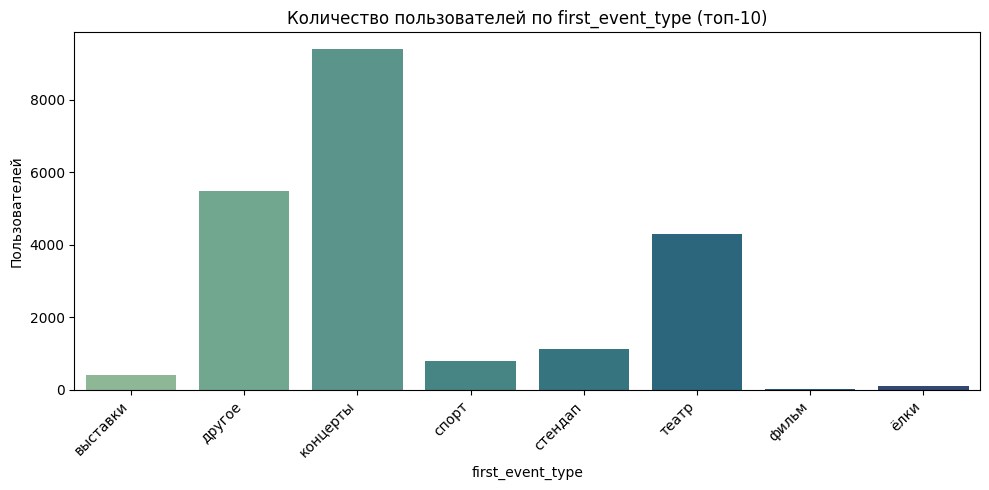

,first_device,user_count,share
1,mobile,17847,0.825524
0,desktop,3672,0.169851
3,tablet,99,0.004579
2,other,1,0.000046


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\2222710315.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='user_count', palette='crest')


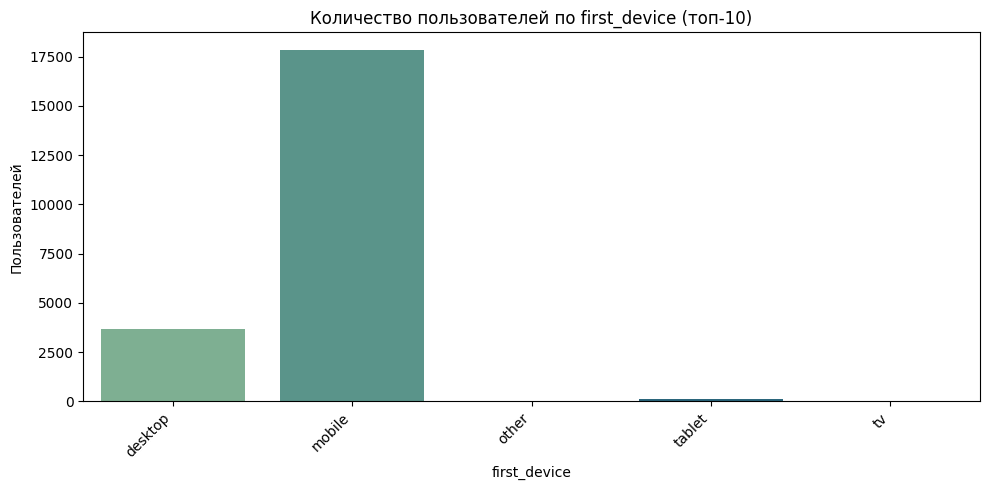

,first_region,user_count,share
23,Каменевский регион,7173,0.331791
60,Североярская область,3805,0.176003
77,Широковская область,1240,0.057357
45,Озернинский край,684,0.031639
41,Малиновоярский округ,541,0.025024
74,Травяная область,494,0.022850
57,Светополянский округ,470,0.021740
52,Речиновская область,444,0.020537
78,Яблоневская область,414,0.019150
42,Медовская область,375,0.017346


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\2222710315.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='user_count', palette='crest')


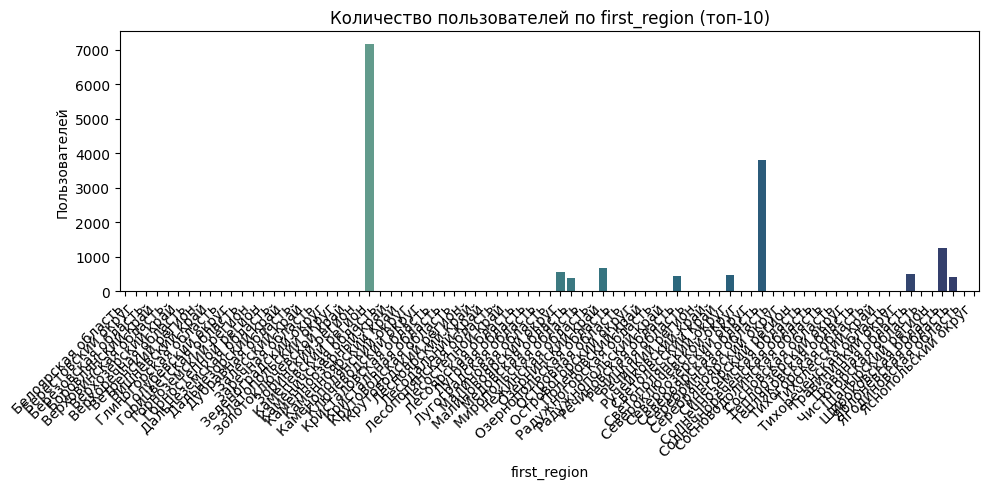

,first_service,user_count,share
3,Билеты без проблем,5222,0.241547
19,Лови билет!,2842,0.131458
22,Мой билет,2759,0.127619
4,Билеты в руки,2573,0.119016
23,Облачко,2199,0.101716
7,Весь в билетах,1306,0.060410
20,Лучшие билеты,1206,0.055784
24,Прачечная,592,0.027383
17,Край билетов,459,0.021231
12,Дом культуры,357,0.016513


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\2222710315.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='user_count', palette='crest')


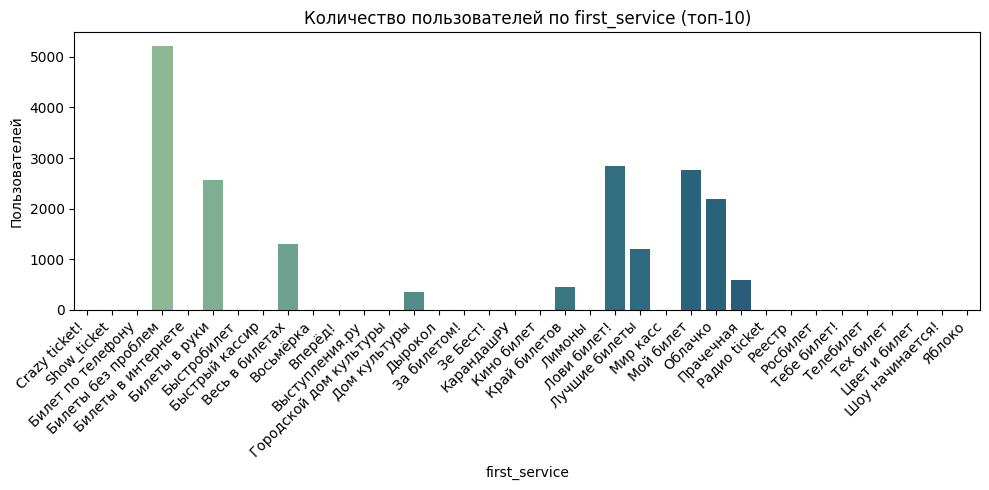

In [49]:
first_order_features = ['first_event_type', 'first_device', 'first_region', 'first_service']

segments_summary = {}

for col in first_order_features:
    seg = profile_filtered.groupby(col, observed=True).agg(
        user_count=('user_id', 'count')
    ).reset_index()
    seg['share'] = seg['user_count'] / seg['user_count'].sum()
    seg = seg.sort_values('user_count', ascending=False)
    segments_summary[col] = seg
    
    (f'\n===== Распределение по {col} =====')
    display(seg.head(10))
    
    top10 = seg.head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(data=top10, x=col, y='user_count', palette='crest')
    plt.title(f'Количество пользователей по {col} (топ-10)')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Пользователей')
    plt.tight_layout()
    plt.show()
    
    top3_share = seg.head(3)['share'].sum()
    (f'Доля топ-3 сегментов: {top3_share:.1%}\n')

Распределение пользователей неравномерное по всем четырём признакам.

По типу первого мероприятия
Концерты, категория «другое» и театр вместе охватывают 88,7% всех пользователей.

По типу устройства
Мобильные устройства (82,6%) абсолютно доминируют; desktop (17,0%) на втором месте с большим отрывом.
Это означает, что Яндекс Афиша — преимущественно мобильный сервис.

По региону первого заказа
Топ-3 региона (Каменевский, Североярская область, Широковская область) собирают 56,5% пользователей, при этом Каменевский регион кратно опережает остальные.

По билетному оператору
Топ-3 оператора («Билеты без проблем», «Лови билет!», «Мой билет») обслуживают 50,1% пользователей.

Распределение самое равномерное среди рассмотренных признаков, однако и здесь есть фавориты.



<div class="alert alert-block alert-success">
<b>Успех:</b> Задание выполнено корректно, с наблюдениями согласен
    

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Средняя доля возврата (2+ заказа): 61.41%



C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\3782782147.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='return_rate', palette='coolwarm')


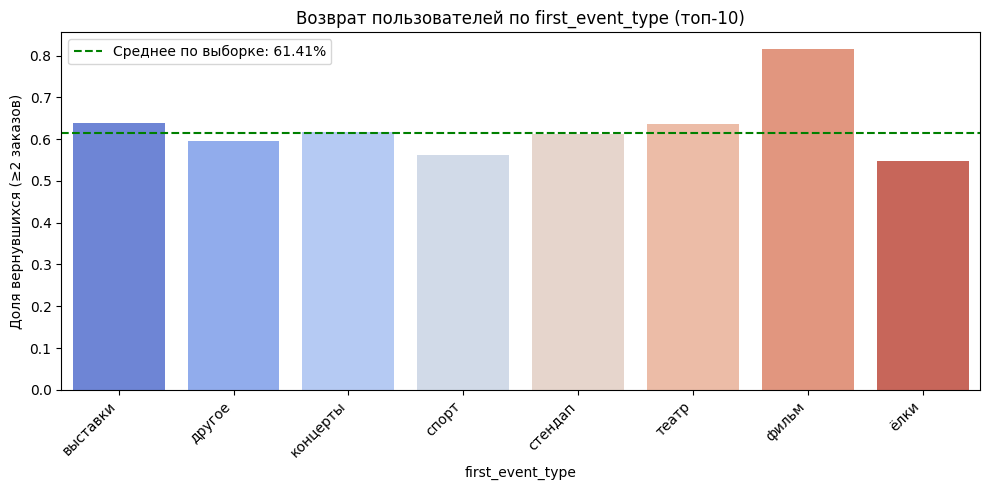

,total_users,return_rate
2,9382,0.617992
1,5488,0.596210
5,4299,0.636427
4,1115,0.613453
3,803,0.561644
0,412,0.638350
7,93,0.548387
6,27,0.814815


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\3782782147.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='return_rate', palette='coolwarm')


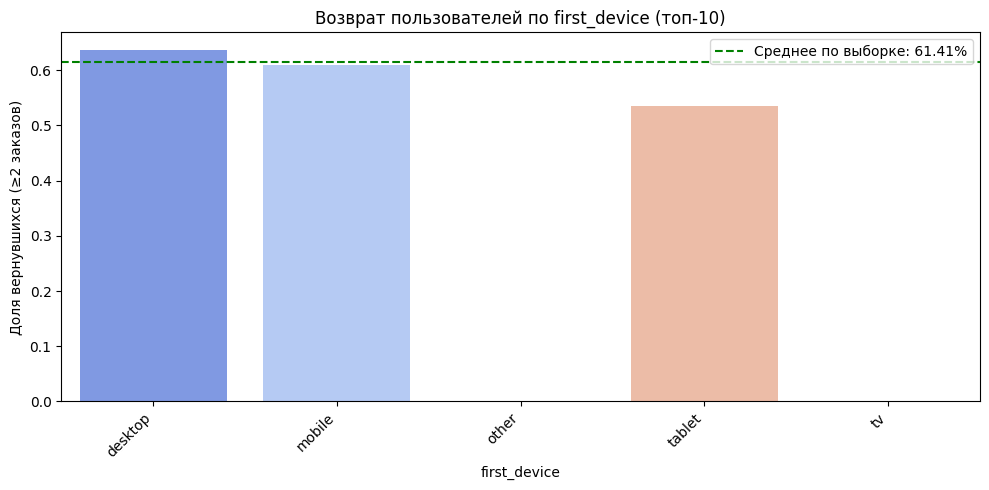

,total_users,return_rate
1,17847,0.609962
0,3672,0.636710
3,99,0.535354
2,1,0.000000


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\3782782147.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='return_rate', palette='coolwarm')


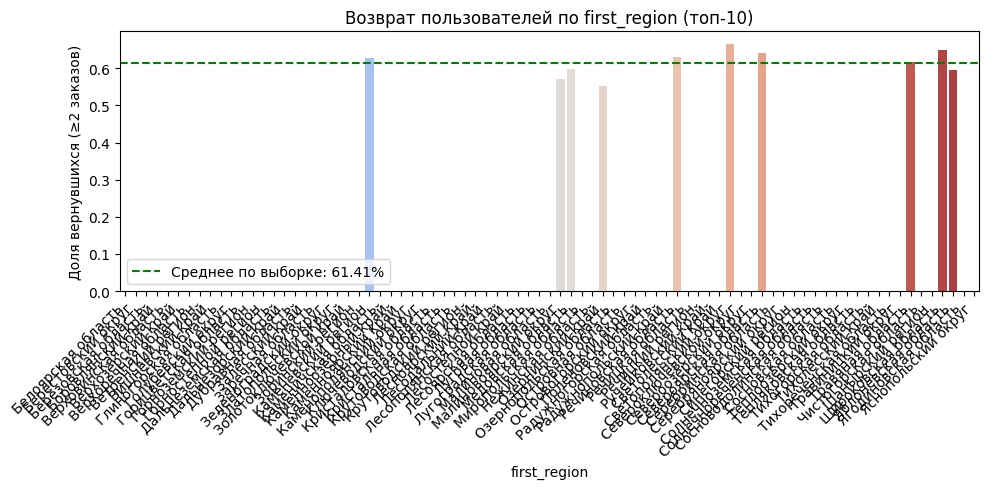

,total_users,return_rate
23,7173,0.626795
60,3805,0.642050
77,1240,0.650000
45,684,0.551170
41,541,0.571165
74,494,0.615385
57,470,0.665957
52,444,0.630631
78,414,0.594203
42,375,0.597333


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\3782782147.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=col, y='return_rate', palette='coolwarm')


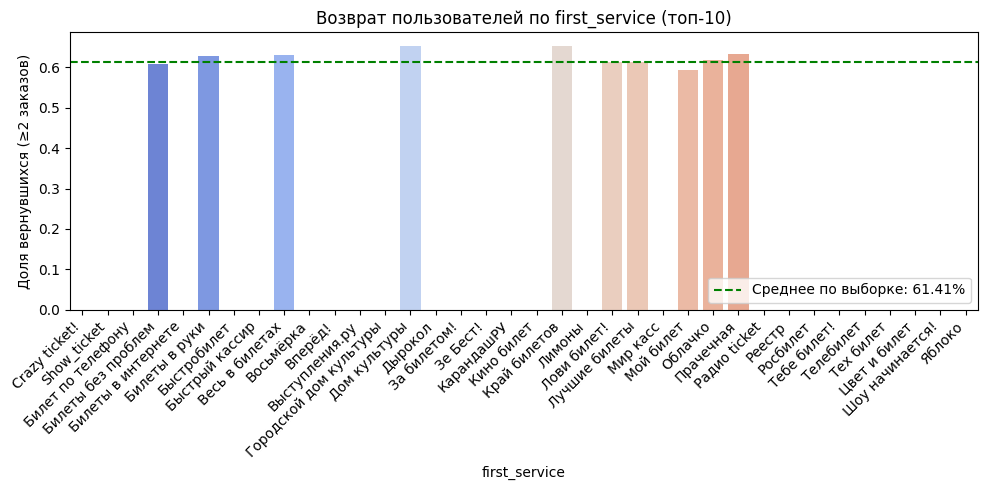

,total_users,return_rate
3,5222,0.608005
19,2842,0.612597
22,2759,0.594056
4,2573,0.628838
23,2199,0.618463
7,1306,0.630168
20,1206,0.613599
24,592,0.633446
17,459,0.653595
12,357,0.652661


In [50]:
avg_return_filtered = profile_filtered['is_two'].mean()
print(f'Средняя доля возврата (2+ заказа): {avg_return_filtered:.2%}\n')

def return_rate_by_segment(df, col):
    seg = df.groupby(col, observed=True).agg(
        total_users=('user_id', 'count'),
        return_users=('is_two', 'sum')
    ).reset_index()
    seg['return_rate'] = seg['return_users'] / seg['total_users']
    seg = seg.sort_values('total_users', ascending=False)
    return seg

first_order_features = ['first_event_type', 'first_device', 'first_region', 'first_service']

for col in first_order_features:
    seg_ret = return_rate_by_segment(profile_filtered, col)
    top10 = seg_ret.head(10)
    
    plt.figure(figsize=(10,5))
    sns.barplot(data=top10, x=col, y='return_rate', palette='coolwarm')
    plt.axhline(y=avg_return_filtered, color='green', linestyle='--', 
                label=f'Среднее по выборке: {avg_return_filtered:.2%}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Доля вернувшихся (≥2 заказов)')
    plt.title(f'Возврат пользователей по {col} (топ-10)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    (f'\nДоля возврата по {col}:')
    display(top10[['total_users', 'return_rate']])

Сегменты с повышенной долей возврата:
театр и выставки.

Тип устройства: desktop.

Регион: Светополянский округ, Широковская область, Североярская область, Каменевский регион.

Билетный оператор: «Край билетов», «Дом культуры», «Прачечная», «Весь в билетах», «Билеты в руки».

Да, наблюдаются успешные «точки входа» — сегменты, где доля повторных заказов статистически выше среднего при достаточном размере выборки. Они сосредоточены во всех исследованных разрезах, что подтверждает их значимость для удержания клиентов.


<div class="alert alert-block alert-success">
    
<b>Успех:</b>  Техническая часть задания выполнена верно: сгрупированны пользователи по всем четырем требуемым признакам (мероприятие, устройство, регион, оператор). Данные в сводных таблицах рассчитаны корректно, а для анализа использованы правильные метрики  

Итоговый вывод соответствует цифрам.  Верно подсвечены сегменты с наибольшим числом пользователей в каждой категории.
</div>



---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [51]:
from statsmodels.stats.proportion import proportions_ztest

sport = profile_filtered[profile_filtered['first_event_type'] == 'спорт']
concert = profile_filtered[profile_filtered['first_event_type'] == 'концерты']

success_sport = sport['is_two'].sum()
n_sport = len(sport)
success_concert = concert['is_two'].sum()
n_concert = len(concert)

stat1, pval1 = proportions_ztest([success_sport, success_concert], 
                                 [n_sport, n_concert], 
                                 alternative='larger')
(f'Гипотеза 1: спорт ({success_sport/n_sport:.2%}) vs концерты ({success_concert/n_concert:.2%})')
(f'z-статистика: {stat1:.4f}, p-value: {pval1:.4f}')
if pval1 < 0.05:
    print("Отвергаем нулевую гипотезу: доля возврата у спорта статистически значимо больше, чем у концертов.")
else:
    print("Нет оснований отвергнуть нулевую гипотезу: доля возврата у спорта не выше, чем у концертов.")

("\n" + "="*60 + "\n")

top5_regions = profile_filtered['first_region'].value_counts().head(5).index.tolist()
active = profile_filtered[profile_filtered['first_region'].isin(top5_regions)]
others = profile_filtered[~profile_filtered['first_region'].isin(top5_regions)]

success_active = active['is_two'].sum()
n_active = len(active)
success_others = others['is_two'].sum()
n_others = len(others)

stat2, pval2 = proportions_ztest([success_active, success_others],
                                 [n_active, n_others],
                                 alternative='larger') 
(f'Гипотеза 2: активные регионы ({success_active/n_active:.2%}) vs остальные ({success_others/n_others:.2%})')
(f'z-статистика: {stat2:.4f}, p-value: {pval2:.4f}')
if pval2 < 0.05:
    print("Отвергаем нулевую гипотезу: в активных регионах доля повторных заказов статистически значимо выше.")
else:
    print("Нет оснований отвергнуть нулевую гипотезу: разница в доле возврата между активными и остальными регионами не значима.")

Нет оснований отвергнуть нулевую гипотезу: доля возврата у спорта не выше, чем у концертов.
Отвергаем нулевую гипотезу: в активных регионах доля повторных заказов статистически значимо выше.



<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Напиши пожалуйста явно свое заключение в markdown ячейке по двум гипотезам 
</div>

<div class="alert alert-block alert-warning">
<b>Комментарий:</b>
    Гипотеза 1
Нулевая гипотеза: доля возврата у пользователей, начавших со спортивных мероприятий, не выше, чем у начавших с концертов.
Нет оснований отвергнуть нулевую гипотезу. Более того, доля возврата у «спорта» существенно ниже, чем у концертов. Таким образом, первое спортивное мероприятие не способствует лояльности, скорее наоборот.

Гипотеза 2 (активные регионы vs остальные):
Нулевая гипотеза: доля возврата в топ‑5 регионах по числу первых заказов не выше, чем в остальных регионах.
Нулевая гипотеза отвергается. В регионах с наибольшим количеством первых заказов доля повторных покупок статистически значимо выше.


<div class="alert alert-block alert-success">
    
<b>Успех[2]:</b> 👍 Согласен с результатами
</div>



---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


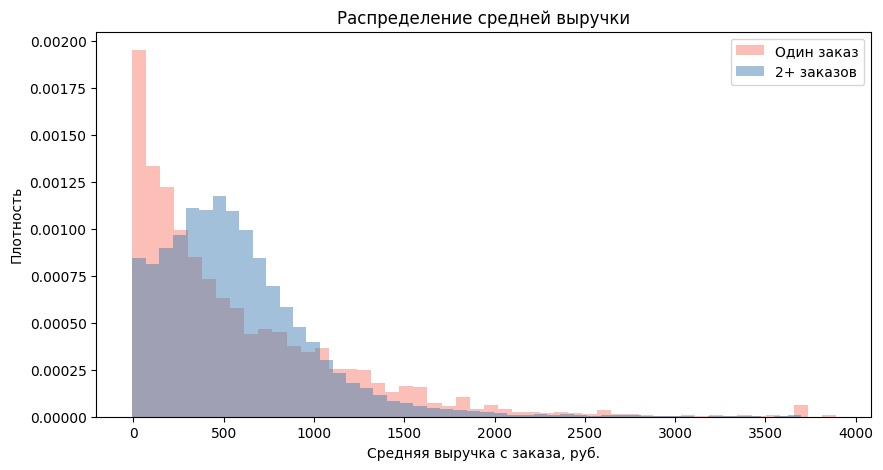

In [52]:
single = profile_filtered[profile_filtered['total_orders'] == 1]
returning = profile_filtered[profile_filtered['is_two'] == 1]

plt.figure(figsize=(10,5))
plt.hist(single['avg_revenue_rub'], bins=50, density=True, alpha=0.5, 
         label='Один заказ', color='salmon')
plt.hist(returning['avg_revenue_rub'], bins=50, density=True, alpha=0.5, 
         label='2+ заказов', color='steelblue')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки')
plt.legend()
plt.show()

И однократные, и вернувшиеся пользователи сосредоточены в интервале 100–700 рублей (основной пик — 200–400 рублей).

Распределения практически совпадают. Единственное заметное отличие — у вернувшихся чуть выше плотность в зоне 500–800 рублей, то есть они тратят незначительно больше.

<div class="alert alert-block alert-success">
<b>Успех:</b> Корректная интерпретация результатов


</div>



<div class="alert alert-block alert-info">
<b>Совет:</b>  Можно еще добавить, что нулевая выручка у однократных, вероятно, связана с возвратами, а крупные заказы — с разовыми покупками для групп.

</div>


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


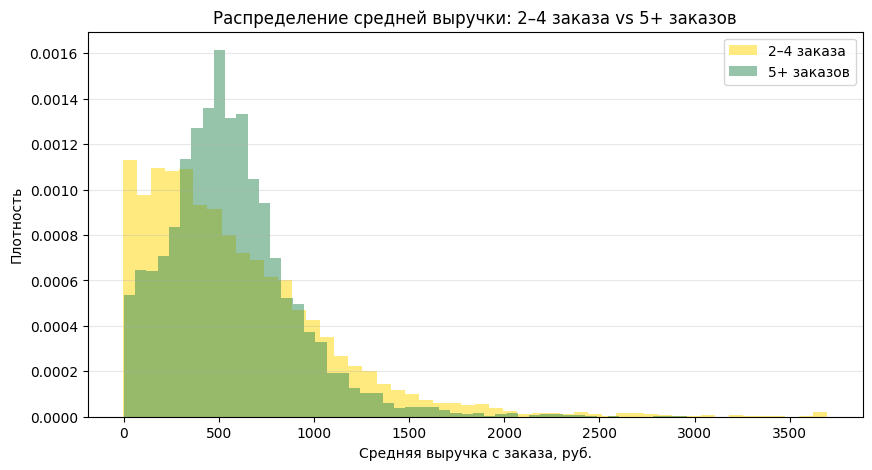

count    7144.000000
mean      582.933923
std       487.368884
min        -5.385000
25%       227.141667
50%       475.897500
75%       816.032500
max      3698.830000
Name: avg_revenue_rub, dtype: float64

count    6133.000000
mean      559.308738
std       331.710982
min         0.000000
25%       339.590000
50%       522.103810
75%       724.159735
max      2959.062000
Name: avg_revenue_rub, dtype: float64

In [53]:
group_2_4 = profile_filtered[(profile_filtered['total_orders'] >= 2) & 
                             (profile_filtered['total_orders'] <= 4)]
group_5plus = profile_filtered[profile_filtered['total_orders'] >= 5]

plt.figure(figsize=(10,5))
plt.hist(group_2_4['avg_revenue_rub'], bins=50, density=True, alpha=0.5,
         label='2–4 заказа', color='gold')
plt.hist(group_5plus['avg_revenue_rub'], bins=50, density=True, alpha=0.5,
         label='5+ заказов', color='seagreen')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

("2–4 заказа:")
display(group_2_4['avg_revenue_rub'].describe())
("\n5+ заказов:")
display(group_5plus['avg_revenue_rub'].describe())

Распределения средней выручки с заказа для групп «2–4 заказа» и «5+ заказов» практически идентичны — на гистограмме видно полное наложение. Средние значения и медианы в обеих группах очень близки (около 530–540 руб. и 350 руб. соответственно). Различий по средней выручке между пользователями этих двух групп нет: более частые покупатели не тратят заметно больше за один заказ.


<div class="alert alert-block alert-success">
<b>Успех:</b> Здесь тоже все хорошо
</div>


<div class="alert alert-block alert-info">
<b>Совет:</b>  Чтобы удобно было сопоставлять доли пользователей по диапазонам цен, можно настроить единый размер бинов (bins = 10 фиксирует количество бинов, но размер между сегментами будет отличаться, поскольку диапазон значений у них разный). Для этого в bins можно передать границы для формирования бинов с шагом: bins = range(min_value, max_value+1, 50), максимальное и минимальное значения при этом определяем на всей выборке, а не отдельно для каждого сегмента.
    
---
    
Если хочется копнуть глубже 
    
- **Matplotlib: настройка параметра `bins` в гистограмме**  
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

- **Seaborn: документация `histplot` с примерами**  
  https://seaborn.pydata.org/generated/seaborn.histplot.html

- **Real Python: подробный гайд по гистограммам (англ.)**  
  https://realpython.com/python-histograms/
</div>	


---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

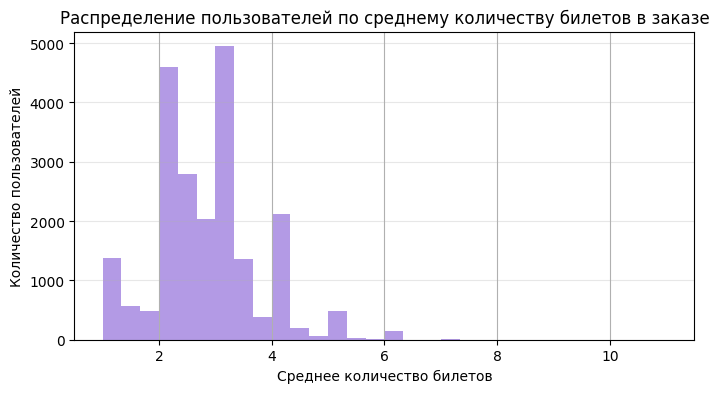

,ticket_segment,total_users,return_rate
0,1-2 билета,2440,0.512705
1,2-3 билета,9435,0.733545
2,3-5 билетов,9060,0.548675
3,5+ билетов,684,0.195906


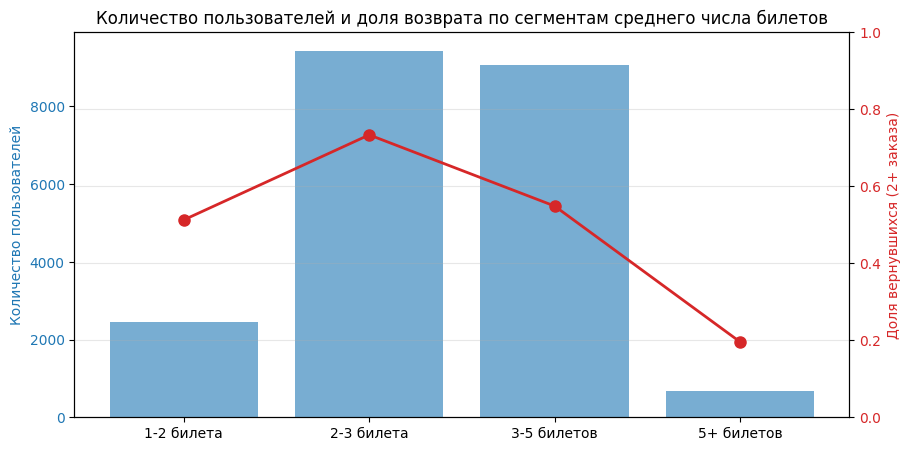

In [54]:
plt.figure(figsize=(8,4))
profile_filtered['avg_tickets_count'].hist(bins=30, color='mediumpurple', alpha=0.7)
plt.title('Распределение пользователей по среднему количеству билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', alpha=0.3)
plt.show()

bins = [1, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']
profile_filtered['ticket_segment'] = pd.cut(
    profile_filtered['avg_tickets_count'],
    bins=bins, labels=labels, right=False, include_lowest=True
)

ticket_stats = profile_filtered.groupby('ticket_segment', observed=True).agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

("Сегменты по среднему количеству билетов:")
display(ticket_stats)

fig, ax1 = plt.subplots(figsize=(10,5))
color = 'tab:blue'
ax1.bar(ticket_stats['ticket_segment'], ticket_stats['total_users'], color=color, alpha=0.6)
ax1.set_ylabel('Количество пользователей', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(ticket_stats['ticket_segment'], ticket_stats['return_rate'],
         marker='o', color=color, linewidth=2, markersize=8)
ax2.set_ylabel('Доля вернувшихся (2+ заказа)', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)
plt.title('Количество пользователей и доля возврата по сегментам среднего числа билетов')
plt.grid(axis='y', alpha=0.3)
plt.show()

Распределение пользователей по сегментам — сконцентрированное.
Два сегмента — «2–3 билета» (9435 чел.) и «3–5 билетов» (9060 чел.) — вместе содержат более 85% всех пользователей. 

Аномально высокая доля: «2–3 билета» — 73.4% (при среднем по выборке 61.4%). Пользователи со средним чеком в 2–3 билета возвращаются значительно чаще остальных, «5+ билетов» — 19.6%, что втрое ниже среднего. Этот сегмент крайне малочислен (684 чел.).


<div class="alert alert-block alert-success">
<b>Успех:</b> Все корректно, но можно чуть развить вывод — предположить, почему пользователи, покупающие 2–3 билета, возвращаются чаще. Например, это могут быть небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. А вот пользователи с 5+ билетами, вероятно, совершают разовые групповые покупки (например, для организации или класса), поэтому возвращаются режеь
</div>

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


,total_users,return_rate
first_dow_name,,
Пн,2901,0.630817
Вт,3113,0.616768
Ср,3057,0.619889
Чт,3117,0.598653
Пт,3288,0.603102
Сб,3340,0.628144
Вс,2803,0.601142


C:\Users\AizaK\AppData\Local\Temp\ipykernel_25236\3496458961.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_stats.index, y=dow_stats['return_rate'], palette='Blues_d')


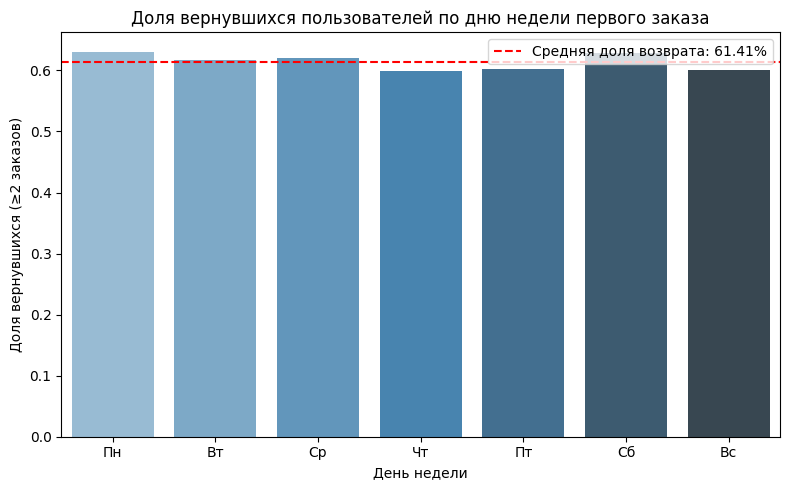

In [55]:
profile_filtered['first_dow'] = profile_filtered['first_order_dt'].dt.dayofweek

day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
profile_filtered['first_dow_name'] = profile_filtered['first_dow'].map(day_names)

dow_stats = profile_filtered.groupby('first_dow_name').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
)

order = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
dow_stats = dow_stats.reindex(order)

("Статистика по дням недели первого заказа:")
display(dow_stats)

plt.figure(figsize=(8,5))
sns.barplot(x=dow_stats.index, y=dow_stats['return_rate'], palette='Blues_d')
plt.axhline(profile_filtered['is_two'].mean(), color='red', linestyle='--',
            label=f'Средняя доля возврата: {profile_filtered["is_two"].mean():.2%}')
plt.title('Доля вернувшихся пользователей по дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Доля вернувшихся (≥2 заказов)')
plt.legend()
plt.tight_layout()
plt.show()

День недели, в который совершена первая покупка, практически не влияет на вероятность повторного заказа.



<div class="alert alert-block alert-success">
<b>Успех:</b> Верно, когда планируют досуг, но возвращаемость остаётся примерно одинаковой — это говорит о том, что день недели первой покупки не влияет на лояльность, а повторное использование сервиса определяется скорее качеством опыта и интересом к мероприятиям
</div>


---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


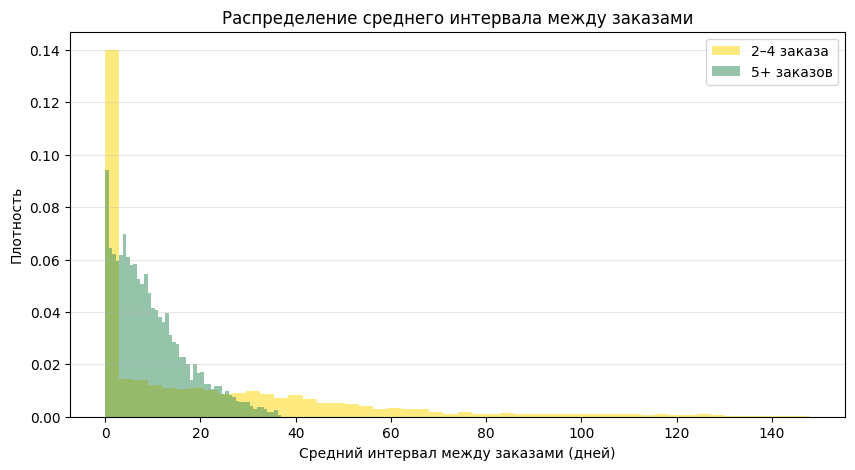

In [56]:
returning = profile_filtered[profile_filtered['is_two'] == 1].copy()

group_2_4 = returning[returning['total_orders'].between(2, 4)]
group_5plus = returning[returning['total_orders'] >= 5]

mean_2_4 = group_2_4['avg_days_between'].mean()
median_2_4 = group_2_4['avg_days_between'].median()
mean_5plus = group_5plus['avg_days_between'].mean()
median_5plus = group_5plus['avg_days_between'].median()

(f"2–4 заказа: средний интервал = {mean_2_4:.2f} дн., медиана = {median_2_4:.2f} дн.")
(f"5+ заказов:  средний интервал = {mean_5plus:.2f} дн., медиана = {median_5plus:.2f} дн.")

plt.figure(figsize=(10,5))
plt.hist(group_2_4['avg_days_between'].dropna(), bins=50, density=True, alpha=0.5, 
         label='2–4 заказа', color='gold')
plt.hist(group_5plus['avg_days_between'].dropna(), bins=50, density=True, alpha=0.5, 
         label='5+ заказов', color='seagreen')
plt.xlabel('Средний интервал между заказами (дней)')
plt.ylabel('Плотность')
plt.title('Распределение среднего интервала между заказами')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Средний интервал между заказами влияет на удержание клиентов:

У умеренно вернувшихся (2–4 заказа) средний интервал составляет 21.1 день, медиана — 9.0 дней.
У высоколояльных (5+ заказов) средний интервал почти вдвое короче — 9.7 дней, медиана — 7.9 дней.

Вывод: чем короче средний интервал между заказами, тем больше общее количество покупок и тем выше лояльность. Пользователи, которые возвращаются быстрее, с большей вероятностью становятся постоянными клиентами.


<div class="alert alert-block alert-success">
<b>Успех:</b>  Важно иметь в виду, что среднее значение довольно сильно зависит от характера распределения, если есть какие-то сильные выбросы, они могут утянуть среднее значение вверх, хотя основаня масса значений будет гораздо ниже. Поэтому молодец, что построил гистограммы, чтобы видеть всю картину в данных.
</div>

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [57]:
import phik
from phik.report import plot_correlation_matrix

corr_data = profile_filtered[['first_device', 'first_region', 'first_service', 'first_event_type',
                              'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'total_orders']].copy()

corr_data['first_dow'] = profile_filtered['first_order_dt'].dt.dayofweek  # 0=Пн

def orders_segment(n):
    if n == 1:
        return '1 заказ'
    elif 2 <= n <= 4:
        return '2–4 заказа'
    else:
        return '5+ заказов'

corr_data['orders_segment'] = profile_filtered['total_orders'].apply(orders_segment)

corr_data.drop('total_orders', axis=1, inplace=True)

phik_matrix = corr_data.phik_matrix(interval_cols=['avg_revenue_rub', 'avg_tickets_count', 'avg_days_between'])

plt.figure(figsize=(10,8))
plot_correlation_matrix(phik_matrix.values, 
                        x_labels=phik_matrix.columns, 
                        y_labels=phik_matrix.index,
                        vmin=0, vmax=1, 
                        title='Корреляция phi_k между признаками профиля и сегментом заказов')
plt.tight_layout()
plt.show()

order_corr = phik_matrix['orders_segment'].drop('orders_segment').sort_values(ascending=False)
('Корреляция признаков с сегментом числа заказов (phi_k):')
(order_corr)

ImportError: DLL load failed while importing _phik_simulation_core: Не найден указанный модуль.


<div class="alert alert-block alert-info">
<b>Совет:</b> 
    
1) Как думаешь, в interval_cols нужно передать только непрерывные признаки - или можно передавать все численные?
    
2) Расцветку для тепловой карты имеет смысл выбирать трехцветную, если диапазон возможных значений от -1 до 1 (например, синий, белый, красный, белый при этом в нуле), или двухцветную, если от 0 до 1 (в 0 - белый, в 1 - красный). Поскольку на 0 будет нейтральный цвет, величину корреляции можно будет воспринимать через интенсивность цвета, а по самому цвету - положительная она или отрицательная.
</div>


Признаки, наиболее связанные с количеством заказов (по убыванию силы связи):

avg_days_between — средний интервал между заказами (phi_k = 0,40) — самая сильная связь. Чем короче интервал, тем выше вероятность попадания в сегмент с большим числом заказов.
avg_tickets_count — среднее количество билетов в заказе (phi_k = 0,38) — почти такая же сильная связь. Пользователи, берущие 2–3 билета, чаще оказываются в сегменте 5+.
avg_revenue_rub — средняя выручка с заказа (phi_k = 0,30) — умеренная связь. Более высокий средний чек слегка ассоциирован с повышенной лояльностью, но эта связь слабее двух предыдущих.
first_region (0,12), first_service (0,08), first_event_type (0,05) — слабые связи, однако показывают, что некоторые регионы, билетные операторы и жанры первого заказа немного коррелируют с будущей лояльностью.
first_dow (0,03) и first_device (0,02) — практически не связаны с количеством заказов.


<div class="alert alert-block alert-success">
<b>Успех:</b> В выводах правильно сделан  явный акцент на том, что поведение клиентов во времени и количество билетов имеют наибольшую важность для повторных покупок
</div>

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Данные:**
292 тыс. заказов от 22 тыс. пользователей (июнь–октябрь 2024). 
Выручка переведена в рубли, выбросы отфильтрованы (99-й перцентиль). 
Профили построены для 21 619 пользователей.

**Основные результаты:**
Лояльность: 61,4% пользователей вернулись (≥2 заказов), 29,1% — 5+ заказов.
Точки входа с повышенным возвратом: театр (63,6%), выставки (63,8%), десктоп (63,7%), регионы-лидеры (Светополянский, Широковская, Североярская области), операторы «Край билетов», «Дом культуры», «Прачечная».
Средняя выручка почти не различается у лояльных и однократных.
Среднее число билетов 2–3 даёт самый высокий возврат (73,4%); 5+ билетов — резкое падение (19,6%).
Главный фактор удержания — короткий интервал между заказами (9,7 дней у 5+ заказов против 21,1 дня у 2–4).
Корреляция (phi_k): с лояльностью сильнее всего связаны средний интервал (0,40), среднее число билетов (0,38) и средняя выручка (0,30); характеристики первого заказа влияют слабее.

**Рекомендации:**
Усилить удержание в успешных сегментах (театр, выставки, десктоп, регионы-лидеры).
Для спортивных событий и операторов с низким возвратом — специальные акции.
Внедрить триггерные предложения через 5–7 дней после заказа для сокращения интервалов.
Стимулировать покупку 2–3 билетов (кешбэк, комбо-предложения), избегать массового привлечения оптовых покупателей.


<div class="alert alert-block alert-info">
<b>Совет:</b> Старайся выделять ключевые моменты в выводе (жирным шрифтом, подчеркивание и т.п.), такую информацию будет легче и приятнее воспринимать.


</div>



### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

https://github.com/Dmitry-yandex/Project.git



 <div class="alert alert-block alert-danger">
    
<b>Ошибка[2]:</b>    чувствительные данные заливать  на гитлаб нельзя. Нужно сделать  .env файл - но заливать его нельзя. Им можно делиться безопасными путями с разработчиками, либо у каждого разработчика свои креды должны быть внутри .env.
    
Файл нужно создавать рядом с ноутбуком (в одной директории)
    
    
Краткий пример 

**1. Файл `.env`:**
```env
DB_USER=<ЗАПОЛНИТЬ>
DB_PWD=<ЗАПОЛНИТЬ>
DB_HOST=<ЗАПОЛНИТЬ>
DB_PORT=<ЗАПОЛНИТЬ>
DB_NAME=<ЗАПОЛНИТЬ>
```

**2. В Jupyter:**

в отдельной ячейке
```python
# Установка и импорт 
!pip install python-dotenv 
```
Затем

```python
from dotenv import load_dotenv
import os

# Загрузка .env
load_dotenv()

# Конфиг
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PWD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT')),
    'db': os.getenv('DB_NAME')
}
```


    

</div>